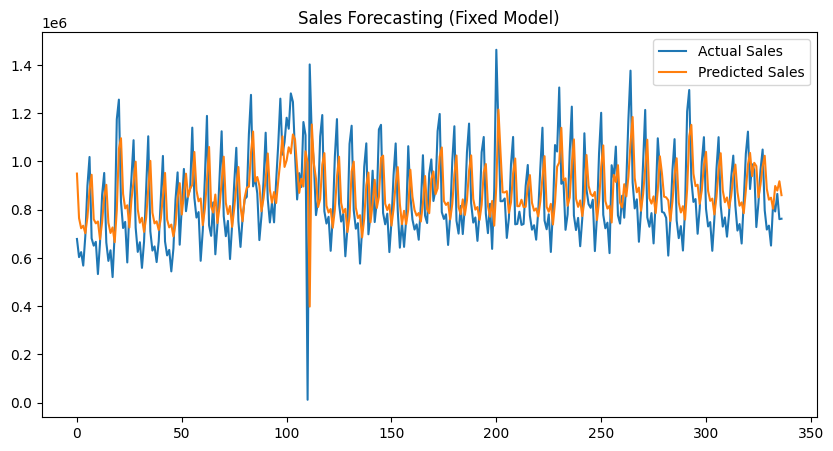

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/train.csv.zip")

# Convert date column
data['date'] = pd.to_datetime(data['date'])

# 🔥 FIX: Group by date
data = data.groupby('date')['sales'].sum().reset_index()

# Sort data
data = data.sort_values('date')

# Feature engineering
data['Year'] = data['date'].dt.year
data['Month'] = data['date'].dt.month
data['Day'] = data['date'].dt.day

# Lag feature
data['Prev_Sales'] = data['sales'].shift(1)

# Drop null
data = data.dropna()

# Features and target
X = data[['Year', 'Month', 'Day', 'Prev_Sales']]
y = data['sales']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")
plt.legend()
plt.title("Sales Forecasting (Fixed Model)")
plt.show()